# Laboratory 3: Adding Captions to Images

This laboratory covers:

* Similarities between image-to-text generation and text-to-image generation
* Building a Transformer from scratch to add captions to images
* Training an image-to-text Transformer with the Flickr 8k dataset
* Adding captions to images with the trained image-to-text Transformer

Training a multi-modal Transformer for text-to-image generation (i.e., adding captions to images) and training one for image-to-text generation (i.e., generating images based on textual descriptions) share several similarities, primarily because both tasks involve learning complex mappings between textual and visual modalities. Understanding and training multi-modal Transformers for image-to-text generation first can provide valuable insights and foundational knowledge, making the more complex task of text-to-image generation more manageable. For this very reason, we will build and train an image-to-text Transformer from scratch in this laboratory to lay a solid foundation for text-to-image generation skills in later laboratories.

Specifically, we will go through all the steps needed to build a multi-modal Transformer to add captions to images. We will use the Flickr 8k dataset as the training data to train the model. Once the model is trained, we can feed any image to the model and obtain a coherent caption describing what is in the image.

Both image-to-text and text-to-image tasks often use similar Transformer-based architectures. These models typically include encoders and decoders that handle different modalities. The architecture is designed to learn representations from both text and images, allowing the model to translate between these modalities.

To train a model to add captions to images in this laboratory, we will create an encoder-decoder Transformer to serve as our image-to-text multi-modal model. To create an encoder, we will build a Vision Transformer (ViT) to help in understanding visual features in images. As we learned in Laboratory 2, the ViT treats an image as a sequence of image patches and extracts features from them. The trained ViT effectively encodes these features and compresses them to a latent space that the natural language model understands.

To create a decoder in the multi-modal model, we will use one similar to the decoder in the German-to-English translator we built in Laboratory 1. The difference lies in the input to the decoder. In Laboratory 1, the input to the decoder is the encoder's output that captures the meaning of a German phrase. The decoder in the German-to-English translator generates the English translation in an autoregressive fashion. It starts with the `BOS` token, which signals the start of a sequence. It then generates the translation one token at a time. In each iteration, it predicts the next token based on the encoder's output and previous text tokens in the sequence.

In this laboratory, the decoder in the image-to-text Transformer works in a similar fashion. The input to the decoder is the encoder's output that captures the feature maps of the input image. The decoder in the image-to-text Transformer generates the caption one text token at a time, starting with the token `BOS`, which signals the start of the caption. In each iteration, it predicts the next token based on the image embedding generated by the ViT encoder and previous tokens in the caption. When the predicted next token is `EOS`, which signals the end of the caption, the image-to-text generation process stops.

Image-to-text models help in understanding how visual features can be effectively encoded and mapped to linguistic features. This knowledge is crucial when reversing the task for text-to-image generation. Successful training of image-to-text models ensures the model can effectively understand and encode visual information, a critical step before attempting to generate visual data from text.

Generating high-quality images that are visually coherent and match the given textual description is a more challenging task. The model must capture complex visual details and produce images that are both realistic and contextually accurate. Ensuring the generated image maintains overall coherence (e.g., correct object shapes, consistent lighting, and textures) adds another layer of complexity. We will tackle these challenges in the rest of the laboratory by using tools such as U-Nets, diffusion models, variational autoencoders, Vision Transformers, and so on.

# 1.	Preparing the Training Dataset
We will use the Flickr 8k dataset to train the image-to-text Transformer in this laboratory.
We chose Flickr 8k to reduce the computational resources needed for training the
model. The Flickr 8k dataset is a collection of more than $8,000$ photographs sourced
from the Flickr website, each annotated with five different descriptive captions provided
by human annotators. This dataset is specifically designed for developing and
evaluating image-captioning models. The diverse set of images typically depicts people
or animals performing various activities in a wide range of settings. The annotations
are intended to facilitate the training of machine learning models that can generate
descriptive text for images automatically. Other datasets for this purpose include the
Flickr 30k dataset, which has about $30,000$ training images, and the MS COCO (Microsoft
Common Objects in Context) dataset, which consists of $328,000$ images.

In this section, we will download the dataset, split the images into a train and test set, and place them in batches for training later.

## 1.1. Downloading and Visualizing Flickr 8k Images
We can download the Flickr 8k images and the associated text captions from Kaggle. We copy everything in the folder `files`.

In [ ]:
import kagglehub, shutil

path = kagglehub.dataset_download("adityajn105/flickr8k")
shutil.copytree("/kaggle/input/flickr8k/Images","files/Images")

Using Colab cache for faster access to the 'flickr8k' dataset.


'files/Images'

Since we need to split data into train and test, we will also download the file `dataset_flickr8k.json` from Google Drive (https://drive.google.com/file/d/1ZUNdI3kw3yP20PYoQpQ8_9KbptFX7cJG/view?usp=drive_link). Place the file `dataset_flickr8k.json` in the `files` folder.

We first read the JavaScript Object Notation (JSON) file, which contains information
about the captions and corresponding tokens for each caption:

In [ ]:
import json

with open('files/dataset_flickr8k.json', 'r') as fb:
    data = json.load(fb)

All the Flickr 8k images should be stored in the `files/Images` folder. We will split them into train and test subsets, as follows:

In [ ]:
from collections import Counter

train_image_paths = []
train_image_captions = []
test_image_paths = []
test_image_captions = []
word_freq = Counter()

max_len=50
for img in data['images']:
    captions = []
    for c in img['sentences']:
        word_freq.update(c['tokens']) #Gathers information about text tokens to create a vocabulary
        if len(c['tokens']) <= max_len:
            captions.append(c['tokens']) #Gathers all captions
    if len(captions) == 0:
        continue
    path ="files/Images/"+img['filename']
    if img['split'] in {'train', 'val', 'restval'}: #Creates a train subset
        train_image_paths.append(path)
        train_image_captions.append(captions)
    elif img['split'] in {'test'}: #Creates a test subset
        test_image_paths.append(path)
        test_image_captions.append(captions)

The list `train_image_paths` contains the image paths of the train set, while `train_image_captions` contains the corresponding captions. Note that the captions have
already been divided into tokens, so we don’t need to tokenize them from scratch.
Alternatively, we can change `c['tokens']` to `c['raw']` in the preceding code cell, collect
the captions, and tokenize them ourselves. The counter object `word_freq` counts
how often each token is used, and we will use the information to build a vocabulary later.

Next, we make sure that the number of images matches the number of groups of captions in both the training and test sets (recall that each image has five captions). We also count the number of observations in the two datasets, as follows:

In [ ]:
assert len(train_image_paths)==len(train_image_captions)
assert len(test_image_paths)==len(test_image_captions)
print(f"there are {len(train_image_paths)} training images")
print(f"there are {len(test_image_paths)} test images")

there are 7000 training images
there are 1000 test images


We have $7,000$ training images and $1,000$ test images.

Next, we create a vocabulary for the English language for text-generation purposes.

## 1.2. Building a Vocabulary of Tokens
Based on the counter object `word_freq`, we will create a vocabulary of English tokens:

In [ ]:
min_word_freq=0
words = [w for w in word_freq.keys() if word_freq[w]>min_word_freq]
word2idx = {k:v + 4 for v,k in enumerate(words)} #Creates a dictionary to map tokens to indices
word2idx['<pad>'] = 0 # Hardcodes in the special tokens
word2idx['<start>'] = 1
word2idx['<end>'] = 2
word2idx['<unk>'] = 3

The dictionary `word2idx` maps English tokens to indices. We manually insert four special
tokens. The padding token `<pad>` (with an index value of `0`) pads the captions in a
batch to the same length so that we can feed them to the Transformer for training later.
The token `<start>` (index value `1`) signals the start of a caption, and `<end>` (index value
`2`) signals the end of a caption. Finally, the token `<unk>` (index value `3`) is used in case
a token isn’t found in the dictionary `word2idx`.

We can use the dictionary `word2idx` to convert captions to a sequence of  indices, as follows:

In [ ]:
indices=[word2idx.get(token,3) for
         token in test_image_captions[0][0]]
print(indices)

[12, 18, 318, 11, 12, 13, 11, 45, 30, 4, 234]


Tokens in the first caption for the first image in the test set are converted to a sequence of numbers, as shown above.

We create another dictionary, `idx2word`, to map integer indices to tokens. Later, we will
use `idx2word` to convert predicted integers back to tokens and then English sentences
in the form of a caption:

In [ ]:
idx2word={v:k for k, v in word2idx.items()} #Creates a dictionary idx2word to map indices to tokens
tokens=[idx2word.get(idx,"<unk>") for
         idx in indices] #Converts the sequence of indices to tokens using the dictionary
print(tokens)
print(f"there are {len(idx2word)} unique tokens")

['the', 'dogs', 'are', 'in', 'the', 'snow', 'in', 'front', 'of', 'a', 'fence']
there are 8387 unique tokens


The dictionary `idx2word` translates a sequence of numbers back to tokens, as shown above. This shows that the first caption for the first image in the test set must be "the dogs are in the snow in front of a fence". The English vocabulary we used to create captions has a
total of $8,387$ unique tokens.

## 1.3. Preparing the Training Dataset
We define a `FlickrD` class to generate image tensors, input tokens, output tokens, and the attention mask.

In [ ]:
import torch
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image

def center_crop(img):
    width, height = img.size
    new=min(width,height)
    left = (width - new)/2
    top = (height - new)/2
    right = (width + new)/2
    bottom = (height + new)/2
    im = img.crop((left, top, right, bottom))
    return im

class FlickrD(Dataset):
    def __init__(self,images,captions,word2idx):
        self.images=images
        self.captions=captions
        self.word2idx=word2idx
        self._max_len = 50
        self.image_size=128
        self._image_transform = self._construct_image_transform(self.image_size)
        self._data = self._create_input_label_mappings()
        self._dataset_size = len(self._data)
        self._start_idx = 1
        self._end_idx = 2
        self._pad_idx = 0
        self._UNK_idx = 3
        self._START_token = "<start>"
        self._END_token = "<end>"
        self._PAD_token = "<pad>"
        self._UNK_token = "<unk>"

    def _construct_image_transform(self, image_size):
        # ImageNet normalization statistics
        normalize = transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225])
        preprocessing = transforms.Compose([
            transforms.ToTensor(),
            normalize,])
        return preprocessing
    def _load_and_process_images(self):
        # Load images
        images_raw = [center_crop(Image.open(path)).resize((self.image_size,
           self.image_size)) for path in self.images]
        # Adapt the images to CNN trained on ImageNet { PIL -> Tensor }
        image_tensors = [self._image_transform(img) for img in images_raw]
        images_processed = {img_name: img_tensor for img_name, img_tensor
                            in zip(self.images, image_tensors)}
        return images_processed

    def _group_captions(self):
        grouped_captions = {self.images[i]:self.captions[i]
                            for i in range(len(self.images))}
        return grouped_captions
    def _create_input_label_mappings(self):
        processed_data = []
        for img, caps in self._group_captions().items():
            for cap in caps:
                pair = (img, cap)
                processed_data.append(pair)
        return processed_data


    def _load_and_prepare_image(self, image_name):
        img_pil = center_crop(Image.open(image_name)).resize((self.image_size,
             self.image_size))
        image_tensor = self._image_transform(img_pil)
        return image_tensor


    def __len__(self):
        return self._dataset_size

    def __getitem__(self, index):
        # Extract the caption data
        image_id, tokens = self._data[index]
        # Load and preprocess image
        image_tensor = self._load_and_prepare_image(image_id)
        # Pad the token and label sequences
        tokens = tokens[:self._max_len]
        tokens = [token.strip().lower() for token in tokens]
        tokens = [self._START_token] + tokens + [self._END_token]
        # Extract input and target output
        input_tokens = tokens[:-1].copy()
        tgt_tokens = tokens[1:].copy()

        # Number of words in the input token
        sample_size = len(input_tokens)
        padding_size = self._max_len - sample_size

        if padding_size > 0:
            padding_vec = [self._PAD_token for _ in range(padding_size)]
            input_tokens += padding_vec.copy()
            tgt_tokens += padding_vec.copy()

        # Apply the vocabulary mapping to the input tokens
        input_tokens = [self.word2idx.get(token, self._UNK_idx)
                        for token in input_tokens]
        tgt_tokens = [self.word2idx.get(token, self._UNK_idx)
                      for token in tgt_tokens]

        input_tokens = torch.Tensor(input_tokens).long()
        tgt_tokens = torch.Tensor(tgt_tokens).long()

        # Index from which to extract the model prediction
        # Define the padding masks
        attn_mask = torch.zeros([self._max_len, ])
        attn_mask[:sample_size] = 1.0
        attn_mask = attn_mask.bool()

        return image_tensor, input_tokens, tgt_tokens, attn_mask

The training and test data are generated as follows:

In [ ]:
trainset=FlickrD(train_image_paths,
  train_image_captions,word2idx) #Generates the train subset using the FlickrD class
testset=FlickrD(test_image_paths,
  test_image_captions,word2idx) #Generates the test subset using the FlickrD class

We then use the PyTorch `DataLoader` class to generate data iterators in the train and test subsets:

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(trainset,
                          batch_size=128,
                          shuffle=True) #Uses the PyTorch DataLoader class to generate a data iterator in the train subset
test_loader = DataLoader(testset,
                        batch_size=128,
                        shuffle=True) #Generates a data iterator in the test subset

The generated train and test data loaders can iterate over data during training and
evaluation. The `DataLoader` class provides an efficient way to batch, shuffle, and load
data. For example, we can retrieve a batch of testing images and their corresponding
input indices, output indices, and attention masks. We save them in a file called `tests.pt` for later use:

In [ ]:
test_images,test_tokens,\
    test_targets,test_mask=next(iter(test_loader))

In [ ]:
torch.save((test_images,test_tokens),"files/tests.pt")

The `.pt` extension designates the file format for PyTorch tensors, enabling us to save
tensors directly to files on the computer.

With this, we are done preparing the training dataset. In the next section, we will create
a multimodal Transformer to add captions to images.

# 2. Creating a Multi-Modal Image-to-Text Transformer to Add Captions
In this section, we will create a multi-modal image-to-text Transformer as our model.

## 2.1. Defining a Vision Transformer as the Image Encoder
We will construct a ViT as the encoder in our model. The purpose of the ViT is to compress
an image into an abstract vector representation in the latent space before passing
it to the decoder. First, we define the following `extract_patches()` function to convert an image to patches.

In [ ]:
def extract_patches(image_tensor, patch_size=8):
    bs, c, h, w = image_tensor.size() #Obtains the dimensions of the image tensor
    unfold = torch.nn.Unfold(kernel_size=patch_size,
                             stride=patch_size) #Defines the unfold layer
    unfolded = unfold(image_tensor) #Applies the unfold layer on the image tensor
    unfolded = unfolded.transpose(1, 2).reshape(bs,
                    -1, c * patch_size * patch_size) #Reshapes the unfolded tensor to the desired shape
    return unfolded

The `extract_patches()` function takes an image and applies an unfold layer to it. Each
input image has a shape of $(3, 128, 128)$; the width and height of the image is $128$ pixels.
Each patch is $8 \times 8$ pixels tall, so each image is divided into a $16 \times 16$ grid ($128 ÷ 8
= 16$). Therefore, the image is divided into $16 \times 16 = 256$ patches. Each patch in each
color channel has $8 \times 8 = 64$ pixels. Because there are three color channels, the total
number of pixels in each patch is $3 \times 64 = 192$.

Note that the PyTorch `Unfold(kernel_size, stride)` layer extracts sliding local
blocks (or patches) from an input tensor. The `kernel_size` argument is the size of the
block to extract (an $8 \times 8$ patch in our example). The `stride` argument is the step size
for moving the window across the input, which is `8` in our example.

Given an input of shape `(N, C, H, W)`, the output will be a tensor of shape `(N, C × kernel_height × kernel_width, L)`, where `L` is the total number of sliding blocks. If we
apply the `Unfold` layer on one image with an input shape of `(1, 3, 128, 128)`, the output
has a shape of `(1, 192, 256)`: one image in the batch, each image patch has $3 \times 8 \times 8
= 192$ pixels, and there are a total of $256$ sliding blocks.

We can verify the results by passing an image through the `extract_patches()` function
and printing out the shape of the output:

In [ ]:
image=test_images[0].unsqueeze(0) #Selects an image from the test subset
patches=extract_patches(image,patch_size=8) #Applies the extract_patches() function on the image
print(patches.shape) #Prints out the dimensions of the output

torch.Size([1, 256, 192])


We pass the first image in the test set through the `extract_patches()` function, and the
output has a shape of `(1, 256, 192)`. The unfold layer converts each image tensor into
a tensor of `(192, 256)`, where `256` represents the number of patches in each image, and
`192` is the number of pixels in each patch. The `extract_patches()` function reshapes
the output from the unfold layer as `(1, 256, 192)`; there’s one image in the batch. The
image is converted to a sequence of `256` image patches. Each image patch is represented
by a `192`-value vector.

The ViT treats an image as a sequence of patches. These patches have orders.
To model the orders of patches in a sequence, we define the following `SinusoidalPosEmb` class:

In [ ]:
import math
from torch import nn

class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, x):
        device = x.device
        half_dim = self.dim // 2
        emb = math.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim,
                                 device=device) * -emb)
        emb = x[:, None] * emb[None, :]
        emb = torch.cat((emb.sin(), emb.cos()), dim=-1)
        return emb

Here, we use fixed positional encoding as we
did in Laboratory 1.

Like other Transformers, we use multi-head attention when building the encoder
layers. We, therefore, define the `AttentionBlock` class as follows:

In [ ]:
class AttentionBlock(nn.Module):
    def __init__(self, hidden_size=128, num_heads=4, masking=True):
        super(AttentionBlock, self).__init__()
        self.masking = masking
        self.multihead_attn=nn.MultiheadAttention(hidden_size,
                                        num_heads=num_heads,
                                        batch_first=True,
                                        dropout=0.0) #Uses the off-the-shelf MultiheadAttention class in PyTorch
    def forward(self, x_in, kv_in, key_mask=None):
        if self.masking:
            bs, l, h = x_in.shape
            mask = torch.triu(torch.ones(l, l,
                     device=x_in.device), 1).bool() #Creates a mask if calculating masked multi-head attention
        else:
            mask = None #Doesn’t apply the mask otherwise
        return self.multihead_attn(x_in, kv_in, kv_in,
             attn_mask=mask,key_padding_mask=key_mask)[0]

The `AttentionBlock` class will be used several times later. We will use it to calculate
unmasked self-attention when creating the encoder, and we will set the `masking` argument
to `False`. We will use it to calculate masked self-attention when creating the decoder, and we will set the `masking` argument to `True`. We will also use it to calculate cross-attention
between the encoder’s output and the input in the decoder, and we will set the `masking` argument to `False` then as well.

Next, we define a generic `TransformerBlock` class to create a
Transformer block, as shown below. This block can be used as either an
encoder or a decoder.

In [ ]:
class TransformerBlock(nn.Module):
    def __init__(self, hidden_size=128, num_heads=4,
                 decoder=False, masking=True):
        super(TransformerBlock, self).__init__()
        self.decoder = decoder
        self.norm1 = nn.LayerNorm(hidden_size)
        self.attn1 = AttentionBlock(hidden_size=hidden_size,
                                    num_heads=num_heads,
                                    masking=masking)
        if self.decoder:
            self.norm2 = nn.LayerNorm(hidden_size)
            # Self-attention mechanism for the decoder with no masking
            self.attn2 = AttentionBlock(hidden_size=hidden_size,
                            num_heads=num_heads, masking=False)
        # Layer normalization for the output before the MLP
        self.norm_mlp = nn.LayerNorm(hidden_size)
        # Multi-layer perceptron (MLP)
        self.mlp = nn.Sequential(nn.Linear(hidden_size, hidden_size * 4),
                                 nn.ELU(),
                                 nn.Linear(hidden_size * 4, hidden_size))
    def forward(self, x, input_key_mask=None,
                cross_key_mask=None, kv_cross=None):
        # Perform self-attention operation
        x = self.attn1(x, x, key_mask=input_key_mask) + x
        x = self.norm1(x)
        # If decoder, perform additional cross-attention layer
        if self.decoder:
            x = self.attn2(x, kv_cross,key_mask=cross_key_mask) + x
            x = self.norm2(x)
        # Apply MLP and layer normalization
        x = self.mlp(x) + x
        return self.norm_mlp(x)

Both the encoder and decoder of the multimodal image-to-text Transformer consist
of multiple blocks. The `TransformerBlock` class we defined previously serves as the
foundation for creating both encoder and decoder blocks. To construct the encoder,
six encoder blocks are stacked sequentially. Similarly, the decoder is formed by stacking
six decoder blocks. An encoder block processes its input through two main components:
a self-attention layer and a feed-forward network. In contrast, a decoder block
includes three sublayers: (1) a causal self-attention layer, (2) a cross-attention layer that
computes the interaction between the encoder’s output and the previous output of the
decoder, and (3) a feed-forward network. Now we can go ahead and create an encoder.

In [ ]:
class VisionEncoder(nn.Module):
    def __init__(self, image_size, channels_in,
                 patch_size=16, hidden_size=128,
                 num_layers=3, num_heads=4):
        super(VisionEncoder, self).__init__()
        self.patch_size = patch_size
        self.fc_in = nn.Linear(channels_in*patch_size*patch_size,
                               hidden_size)
        seq_length = (image_size // patch_size) ** 2
        self.pos_embedding=nn.Parameter(torch.empty(1,seq_length,
                              hidden_size).normal_(std=0.02))
        # Create multiple Transformer blocks as layers
        self.blocks = nn.ModuleList([
            TransformerBlock(hidden_size, num_heads,
        decoder=False, masking=False) for _ in range(num_layers)
        ])
    def forward(self, image):
        bs = image.shape[0]
        # First, convert images into sequences of patches
        patch_seq = extract_patches(image,
                                    patch_size=self.patch_size)
        patch_emb = self.fc_in(patch_seq)
        # Add a unique embedding to each token embedding
        embs = patch_emb + self.pos_embedding
        # Pass the embeddings through each Transformer block
        for block in self.blocks:
            embs = block(embs)
        return embs

When a batch of images passes through the encoder, we first use the `extract_patches()`
function we defined earlier to convert the images to sequences of image patches. The
sequences then go through a linear layer to be converted to image embeddings. The
positional encodings of these patches are added to the image embeddings. The sum
(which is called input embeddings) then goes through multiple encoder blocks.

## 2.2. Creating the Decoder to Generate Text
We define the following `Decoder` class. The goal of the decoder is
to generate a caption one text token at a time, similar to the decoder in the German-to-English translator we built in Laboratory 1.

In [ ]:
class Decoder(nn.Module):
    def __init__(self, num_emb, hidden_size=128,
                 num_layers=3, num_heads=4):
        super(Decoder, self).__init__()
        # Create an embedding layer for tokens
        self.embedding = nn.Embedding(num_emb, hidden_size)
        # Initialize the embedding weights
        self.embedding.weight.data=0.001*self.embedding.weight.data
        # Initialize sinusoidal positional embeddings
        self.pos_emb = SinusoidalPosEmb(hidden_size)
        # Create multiple Transformer blocks as layers
        self.blocks = nn.ModuleList([
            TransformerBlock(hidden_size, num_heads,
                             decoder=True) for _ in range(num_layers)
        ])
        # Define a linear layer for output prediction
        self.fc_out = nn.Linear(hidden_size, num_emb)

    def forward(self, input_seq, encoder_output,
                input_padding_mask=None,
                encoder_padding_mask=None):
        # Embed the input sequence
        input_embs = self.embedding(input_seq)
        bs, l, h = input_embs.shape
        # Add positional embeddings to the input embeddings
        seq_indx = torch.arange(l, device=input_seq.device)
        pos_emb = self.pos_emb(seq_indx).reshape(1,
                             l, h).expand(bs, l, h)
        embs = input_embs + pos_emb
        # Pass the embeddings through each Transformer block
        for block in self.blocks:
            embs = block(embs,
                           input_key_mask=input_padding_mask,
                           cross_key_mask=encoder_padding_mask,
                           kv_cross=encoder_output)
        return self.fc_out(embs)

The `TransformerBlock` class we defined earlier serves as a building block of the
`Decoder` class. During training, the captions are first tokenized and converted to
sequences of indices. These sequences go through word embedding and positional
encoding, similar to what we have done for the English translation of German phrases
in Laboratory 1. The sum of word embedding and positional encoding is the input
embedding to the decoder blocks. Each decoder block has three sublayers: a multi-head
masked self-attention layer, a multi-head cross-attention layer, and a feed-forward
network.

The masked self-attention layer incorporates a mask to ensure the model predicts
the next token in the caption based solely on the preceding tokens, without considering
future tokens. The cross-attention layer computes attention between the decoder’s
current state and the image embeddings provided by the encoder. This mechanism
ensures that the generated caption aligns with the content of the image.

Finally, we combine the vision encoder with the text decoder to create the image-to-text
Transformer. This is reflected in the `VisionEncoderDecoder` class defined below.

In [ ]:
class VisionEncoderDecoder(nn.Module):
    def __init__(self, image_size, channels_in,
                 num_emb, patch_size=16,
                 hidden_size=128, num_layers=(3, 3),
                 num_heads=4):
        super(VisionEncoderDecoder, self).__init__()
        # Create an encoder and decoder with specified parameters
        self.encoder = VisionEncoder(
            image_size=image_size, channels_in=channels_in,
            patch_size=patch_size, hidden_size=hidden_size,
            num_layers=num_layers[0], num_heads=num_heads)
        self.decoder = Decoder(num_emb=num_emb,
            hidden_size=hidden_size,
            num_layers=num_layers[1], num_heads=num_heads)
    def forward(self, input_image, target_seq, padding_mask):
        # Generate padding masks for the target sequence
        bool_padding_mask = padding_mask == 0
        # Encode the input sequence
        encoded_seq = self.encoder(image=input_image)
        # Decode the target sequence using the encoded sequence
        decoded_seq = self.decoder(input_seq=target_seq,
                         encoder_output=encoded_seq,
                    input_padding_mask=bool_padding_mask)
        return decoded_seq

The `VisionEncoderDecoder` class takes two inputs in the forward pass: an image and
an input sequence. The image is passed through the image encoder to produce the
image embedding. The input sequence is the `<start>` token plus tokens in the caption
associated with the image, as we explained earlier in this laboratory. The decoder
tries to predict the next token after each token in the input sequence. For example,
if the caption associated with the image is “a dog runs”, we will add `<start>` and `<end>`
to the beginning and the end of the caption. We will use `<start> a dog runs` as the input
sequence. We move the input sequence one token to the right and use it as the target
sequence (i.e., ground truth). During training, we feed the input sequence `<start> a dog runs` to the decoder to predict the output sequence. We then compare the output
sequence with the target sequence (`a dog runs <end>`) and calculate the cross-entropy
loss. During training, the model parameters are updated to minimize the loss. Now
that we have both the model and the training data ready, we will train the model and use
it to generate captions for images in the next section.

# 3. Training and Using the Image-to-Text Transformer
We will use the Flickr 8k dataset to train the multimodal image-to-text Transformer. We will
first formally set up the model by using the encoder and decoder defined in the preceding
section. We will then define the loss function, optimizer, and the training loop.

Once the model is trained, we will use it to generate captions for images in the test set.
We will first define a `caption()` function to add captions to images and then apply the
function on images in the test set. Finally, we will place both the original caption and the
generated caption above the images to compare how good the trained model is.

## 3.1.	Training the Encoder–Decoder Transformer
The `VisionEncoderDecoder` class we defined in the previous section takes several
hyperparameters as arguments. Generally speaking, by passing hyperparameters as
arguments, we allow for experimentation with different configurations without modifying
the class code. This is particularly important in tasks where the performance
depends on finding the optimal combination of hyperparameters. We
will not perform hyperparameter tuning here. Instead, we will define a few hyperparameters
for the model based on our training dataset and the task at hand:

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
hidden_size = 192 #Each image token is represented by a 192-value vector
num_layers = (6, 6) #Number of Transformer blocks for the encoder and decoder, respectively
num_heads = 8 #Number of attention heads in multi-head attention
patch_size = 8 #Each image patch is 8 × 8 pixels

The hyperparameter `hidden_size=192` means that each image patch is represented by
a $192$-value vector. Both the encoder and the decoder have six Transformer blocks.
Multiple blocks in both the encoder and decoder are crucial for enhancing the model’s
capacity to learn complex representations and capture long-range dependencies in
the data. We use eight attention heads when calculating multi-head attention. Finally,
each image patch has a size of $8$, meaning both the width and height of each patch are $8$ pixels.

Next, we create an image-to-text Transformer by instantiating the `VisionEncoderDecoder`
class we defined in the previous section:

In [ ]:
caption_model = VisionEncoderDecoder(
    image_size=128, channels_in=3,
    num_emb=len(word2idx), patch_size=patch_size,
    num_layers=num_layers,hidden_size=hidden_size,
    num_heads=num_heads).to(device)

The `num_emb` argument in the `VisionEncoderDecoder` class equals the number of
unique tokens in the English vocabulary. The output of the model is the probability
distribution over the vocabulary.

We choose the Adam optimizer with a learning rate of $0.0001$. Because the model
is essentially a multicategory classification problem (which token to choose from the
vocabulary), we will use the cross-entropy loss function:

In [ ]:
# Initialize the optimizer with the above parameters
from torch import nn

optimizer = torch.optim.Adam(caption_model.parameters(),
                             lr=0.0001)
scaler = torch.amp.GradScaler("cuda")
# Define the loss function
loss_fn = nn.CrossEntropyLoss(reduction="none")

We also use PyTorch’s automatic mixed-precision package `torch.amp` to speed up training.
The package provides an automatic mixed precision, where some operations use
`float32` and others `float16`. Doing so reduces the training time. Let’s count the number
of parameters in the model:

In [ ]:
num_model_params = 0
for param in caption_model.parameters():
    num_model_params += param.flatten().shape[0]
print(f"This model has {num_model_params} parameters")

This model has 9545219 parameters


The model has close to $10$ million parameters.

We train the model using batches of training data we prepared earlier.
The weights in the image-to-text Transformer we just created are randomly initialized,
as is typical for an untrained neural network. During training, the model processes the
data to adjust its weights, enabling it to learn associations between images and their
corresponding captions.

In [ ]:
from tqdm import tqdm
for epoch in range(0, 50): #Trains the model for 50 epochs
    caption_model.train()
    eloss=0
    for images,inputs,outputs,masks in tqdm(train_loader):
        images = images.to(device)
        tokens_in = inputs.to(device)
        padding_mask = masks.to(device)
        target_ids = outputs.to(device)
        with torch.amp.autocast("cuda"):
            pred = caption_model(images, tokens_in, #Passes the image and input sequence of the caption through the model to generate predictions
                                 padding_mask=padding_mask)
            loss = (loss_fn(pred.transpose(1, 2), #Calculates the loss by comparing the predictions with the actual output sequence
                            target_ids) * padding_mask).mean()
        optimizer.zero_grad()
        scaler.scale(loss).backward() #Backpropagation: modify model parameters to minimize the cross-entropy loss
        scaler.step(optimizer)
        scaler.update()
        eloss+=loss.item()
    print(f"epoch {epoch}, loss is {eloss/len(train_loader)}")
torch.save(caption_model.state_dict(),"files/caption.pth")

100%|██████████| 274/274 [04:12<00:00,  1.09it/s]


epoch 0, loss is 1.374983905005629


 55%|█████▌    | 151/274 [02:19<01:53,  1.08it/s]


KeyboardInterrupt: 

For simplicity, we train the model for $50$ epochs. We can use early stopping
to determine how many epochs to train, as we did in Laboratory 2, based on the performance
of the model on a validation set. In each epoch, we iterate through batches
of training data, which consist of images, input sequences, target sequences, and the
padding mask. The input sequences are indices corresponding to `<start>` plus the
tokens in the captions. For example, if the caption for an image is “a dog runs”, the
input sequence is `<start> a dog runs` while the target sequence is `a dog runs <end>`.
We train the model to predict the next token in the sequence based on all previous
tokens.

Alternatively, the pretrained model can be downloaded from Google Drive https://drive.google.com/file/d/1_O3dfGCwA3EjHFe65dOl-OIKDHhHJpDB/view?usp=drive_link.

## 3.2. Adding Captions to Images with the Trained Model
Now that the model is trained, we will use it to add captions to images. We first define
the `caption()` function, as shown below. The function uses the encoder in the
trained model to convert an image into the image embedding and passes it to the
decoder. The decoder then generates a caption based on the image embedding one
token at a time.

In [ ]:
def caption(image,temp=1.0):
    # Add the Start-Of-Sequence token to the prompt
    sos_token = 1 * torch.ones(1, 1).long()
    log_tokens = [sos_token]
    caption_model.eval()
    with torch.no_grad():
        # Encode the input image
        image_embedding = caption_model.encoder(image.to(device))
        # Generate the caption tokens
        for i in range(50):
            input_tokens = torch.cat(log_tokens, 1)
            # Decode input tokens into the next predicted tokens
            data_pred = caption_model.decoder(
                input_tokens.to(device),image_embedding)
            # Sample from the distribution based on temperature
            dist = Categorical(logits=data_pred[:, -1] / temp)
            next_tokens = dist.sample().reshape(1, 1)
            # Append the next predicted token to the sequence
            log_tokens.append(next_tokens.cpu())
            # Stop if the End-Of-Caption token is predicted
            if next_tokens.item() == 2:
                break
    # Convert the list of token indices to a tensor
    pred_text = torch.cat(log_tokens, 1)
    pred_text_strings = [idx2word.get(i,"<unk>") for
                 i in pred_text[0].tolist() if i>3]
    # Join the token strings to form the predicted text
    pred_text = " ".join(pred_text_strings)
    return pred_text

The function takes an image as input. It first uses the trained model to encode the
image into image embeddings. It then starts the captioning process using the `<start>`
token as the first element in the caption. The model predicts the next token based on
the image embeddings and the `<start>` token. The predicted token is then added to
the caption and used as the new caption. In the second iteration, the function predicts
the next token based on the updated caption. The process continues until the next
predicted token is `<end>`, which signals the end of the captioning process.

There’s an optional argument, `temp`, in the `caption()` function. The default value of
`temp` is `1`. The creativity of the generated text can be controlled by using the temperature
argument, `temp`. Temperature adjusts the distribution of probabilities assigned to
each potential token before selecting the next one. It effectively scales the logits, which
are the inputs to the softmax function calculating these probabilities, by the value of the
temperature. When the temperature is greater than $1$, the logits are scaled down. This makes the softmax probabilities more uniform, meaning the model is more likely to
sample less likely tokens. When the temperature is less than $1$, the logits are scaled
up. This sharpens the softmax probabilities, making the model more confident in
its predictions and more likely to choose the most likely tokens. To compare the
generated captions with the original captions in the test set, we define the `compare()`
function.

In [ ]:
def compare(images, captions, index, temp=1.0):
    image = images[index].unsqueeze(0) #Retrieves the image from the test set
    capi=captions[index] #Retrieves the caption from the test set
    capt=[idx2word.get(i,"<unk>") for i in capi.tolist() if i>3]
    cap=" ".join(capt)
    pred=caption(image,temp=temp) #Generates a caption using the trained model
    out=torchvision.utils.make_grid(image, 1, normalize=True)
    plt.figure(figsize=(5,10),dpi=100)
    out = torchvision.utils.make_grid(image, 1, normalize=True)
    plt.imshow(out.numpy().transpose((1, 2, 0)))
    plt.title( #Plots the image with both the generated caption and the original caption
    f"**Original caption:\n"+cap+"\n**Generated caption:\n"+pred,
              wrap=True, loc="left", fontsize=18)
    plt.axis("off")
    plt.show()

The `compare()` function retrieves the image and caption from the test set, based on the
`index` argument. It then uses the `caption()` function we defined earlier to generate a
caption. We then plot the image with both the generated caption and the original caption
on top of the image.

We can apply the `caption()` function on any of the images in the test set. For
example, by setting the index argument to `0`, we can apply the function on the first
image:

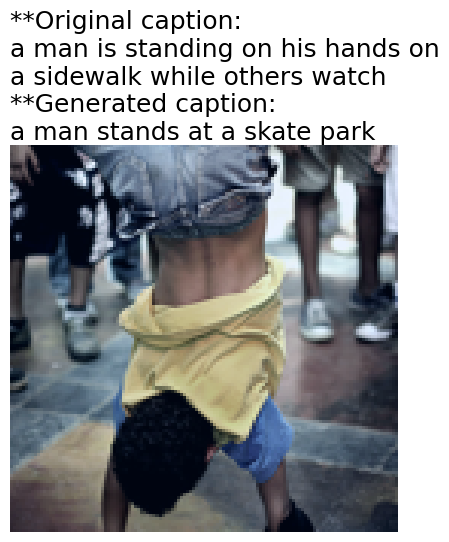

In [ ]:
from torch.distributions import Categorical
import torchvision
import matplotlib.pyplot as plt

caption_model.load_state_dict(torch.load("files/caption.pth",
    weights_only=True,
    map_location=device))

compare(test_images,test_tokens, 0, temp=0.75)

The first two arguments in the `compare()` function are the images and sequence of
indices for the caption tokens. We set these two arguments to `test_images` and `test_tokens`, which means we use examples in the test set. The index value is set to `0`, and
this means we apply the function on the very first image in the test set. We set the `temp`
argument to `0.75`, so the generated caption is predictable and coherent.

# Exercises

1.   Convert the tokens in the third caption for the second image in the test set into
a sequence of integers. Name the sequence `indices2`. Print out the values in
`indices2`.

2.   Use the dictionary `idx2word` to convert the sequence of integers, `indices2`, that you
generated in Exercise 1 into a sequence of tokens.

3.   Apply the `compare()` function on the $10$th image in the test set, and set the `temp` argument
to `0.95`.